<a href="https://colab.research.google.com/github/LycanVenom1225/Data-analytics-course-/blob/main/Capstone_NG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests
github= "https://raw.githubusercontent.com/LycanVenom1225/Data-analytics-course-/main/DOHMH_New_York_City_Restaurant_Inspection_Results_20260528_V2.xlsx"
response=requests.get(github)
local_filename = "downloaded_file.xlsx"
with open(local_filename, "wb") as f:
    f.write(response.content)
    df = pd.read_excel(local_filename)
df.head(40)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude
0,50159080,BX CREPES & WAFFLES,Bronx,3532,WHITE PLAINS ROAD,10467.0,3479162503,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.878016,-73.866094
1,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.759110,-73.834161
2,50173812,EARTHBAR,Brooklyn,246,BEDFORD AVENUE,11249.0,3474220302,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.715847,-73.959865
3,50171729,KATI SHOP,0,100,PARK AVE,7024.0,9178681496,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,NaN,NaN
4,50180551,D LA PARA PICA POLLO BRONX,Bronx,3010,JEROME AVENUE,10468.0,3478428671,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.873931,-73.889110
5,50182814,MR. COSTENITO INC.,Brooklyn,1525,GATES AVENUE,11237.0,6462503535,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.698954,-73.912776
6,50186151,LE LOUP,Queens,22-80,STEINWAY ST,11105.0,3476523777,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.771577,-73.907622
7,50178329,APARTMENT RA'EL,Brooklyn,1124,BEDFORD AVENUE,11216.0,9176456228,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.686136,-73.954474
8,50176305,FIRESIDE CAFE INC.,Brooklyn,1957,86 STREET,11214.0,9173598660,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.605122,-73.999096
9,50149829,LA ESQUINA,0,421,8TH AVE,10116.0,2129207434,Mexican,2025-08-26,Violations were cited in the following area(s).,02B,Hot TCS food item not held at or above 140 °F.,Critical,12.0,A,2025-08-26,2026-05-27 06:00:15,Cycle Inspection / Initial Inspection,NaN,NaN


In [2]:
import seaborn as sns

In [3]:
df['CUISINE DESCRIPTION']=df['CUISINE DESCRIPTION'].fillna("No Description")

In [4]:
df['GRADE']=df['GRADE'].fillna("No Grade")

In [5]:
dfBORO=df[df["BORO"].str.contains("0").eq(False)]


In [6]:
dfBORO.dtypes

,0
CAMIS,int64
DBA,object
BORO,object
BUILDING,object
STREET,object
ZIPCODE,float64
PHONE,object
CUISINE DESCRIPTION,object
INSPECTION DATE,datetime64[ns]
ACTION,object


In [7]:
dfflag = dfBORO.groupby(["DBA","BUILDING","STREET","BORO","CUISINE DESCRIPTION","CRITICAL FLAG"]).size().reset_index(name='count_of_flags')
dfflag.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,CRITICAL FLAG,count_of_flags
0,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,Critical,4
1,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,Not Critical,4
2,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,Critical,17
3,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,Not Critical,8
4,$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,Critical,12


In [8]:
dfflag=dfflag[dfflag["CRITICAL FLAG"].str.contains("Not Applicable").eq(False)]

In [37]:

d=dfflag.groupby(["CUISINE DESCRIPTION"])["BORO"].count()
d.head(50)



,BORO
CUISINE DESCRIPTION,
Afghan,22
African,131
American,4113
Armenian,4
Asian/Asian Fusion,510
Australian,6
Bagels/Pretzels,234
Bakery Products/Desserts,1144
Bangladeshi,143


In [10]:
flagpivot=pd.pivot_table(dfflag,index=["DBA","BUILDING","STREET","BORO","CUISINE DESCRIPTION"],columns="CRITICAL FLAG",values="count_of_flags",aggfunc="sum")
flagpivot.head()

,,,,CRITICAL FLAG,Critical,Not Critical
DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,,
#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,4.0,4.0
#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,12.0,7.0
$1.50 UTICA HOT PIZZA,1127,EASTERN PARKWAY,Brooklyn,Pizza,14.0,7.0
$1.50 HOT PIZZA,1751,FULTON STREET,Brooklyn,Pizza,2.0,1.0


In [11]:
flagpivot.columns = [f"{col[0]}_{col[1]}" for col in flagpivot.columns]
flag= pd.DataFrame(flagpivot.to_records())
flag.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,C_r,N_o
0,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,4.0,4.0
1,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
2,$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,12.0,7.0
3,$1.50 UTICA HOT PIZZA,1127,EASTERN PARKWAY,Brooklyn,Pizza,14.0,7.0
4,$1.50 HOT PIZZA,1751,FULTON STREET,Brooklyn,Pizza,2.0,1.0


In [14]:
flag=flag.rename(columns={"C_r":"Critical","N_o":"Not Critical"})

In [95]:
BX=flag[(flag['BORO'].str.contains("Bronx"))]
BK=flag[(flag['BORO'].str.contains("BROOKLYN"))]
QN=flag[(flag['BORO'].str.contains("QUEENS"))]

In [67]:
flagfit=flag[(flag['CUISINE DESCRIPTION'].str.contains("Caribbean")) | (flag['CUISINE DESCRIPTION'].str.contains("Italian")) | (flag['CUISINE DESCRIPTION'].str.contains("Mexican"))
| (flag['CUISINE DESCRIPTION'].str.contains("Latin American")) | (flag['CUISINE DESCRIPTION'].str.contains("Thai")) | (flag['CUISINE DESCRIPTION'].str.contains("Indian"))| (flag['CUISINE DESCRIPTION'].str.contains("Fusion"))
| (flag['CUISINE DESCRIPTION'].str.contains("Donuts")| (flag['CUISINE DESCRIPTION'].str.contains("Chicken")))| (flag['CUISINE DESCRIPTION'].str.contains("Hamburgers"))| (flag['CUISINE DESCRIPTION'].str.contains("Japanese"))]
flagfit.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
1,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
12,1 QUETZAL,7210,NEW UTRECHT AVENUE,Brooklyn,Mexican,3.0,3.0
19,10 02 LOUNGE AND RESTAURANT,806,EAST TREMONT AVENUE,Bronx,Caribbean,4.0,4.0
20,100 FUN,932934,60 STREET,Brooklyn,Asian/Asian Fusion,4.0,1.0
22,100'S RESTAURANT AND GRILL,127-19,MERRICK BOULEVARD,Queens,Caribbean,4.0,4.0


In [68]:
maxboro=flagfit.groupby(["BORO","CUISINE DESCRIPTION"],as_index=False).agg({"Critical":"sum","Not Critical":"sum","DBA":"count"})
maxboro.head()

,BORO,CUISINE DESCRIPTION,Critical,Not Critical,DBA
0,Bronx,Asian/Asian Fusion,89.0,69.0,11
1,Bronx,Caribbean,874.0,675.0,111
2,Bronx,Chicken,953.0,827.0,161
3,Bronx,Chinese/Japanese,3.0,4.0,1
4,Bronx,Donuts,371.0,397.0,74


In [69]:
maxboro["Percent Critical"]=(maxboro["DBA"]/maxboro["Critical"])*100
maxboro.head()


,BORO,CUISINE DESCRIPTION,Critical,Not Critical,DBA,Percent Critical
0,Bronx,Asian/Asian Fusion,89.0,69.0,11,12.359551
1,Bronx,Caribbean,874.0,675.0,111,12.700229
2,Bronx,Chicken,953.0,827.0,161,16.894019
3,Bronx,Chinese/Japanese,3.0,4.0,1,33.333333
4,Bronx,Donuts,371.0,397.0,74,19.946092


In [70]:
maxboro=maxboro.rename(columns={"DBA":"Total Restaurants"})
maxboro.head()

,BORO,CUISINE DESCRIPTION,Critical,Not Critical,Total Restaurants,Percent Critical
0,Bronx,Asian/Asian Fusion,89.0,69.0,11,12.359551
1,Bronx,Caribbean,874.0,675.0,111,12.700229
2,Bronx,Chicken,953.0,827.0,161,16.894019
3,Bronx,Chinese/Japanese,3.0,4.0,1,33.333333
4,Bronx,Donuts,371.0,397.0,74,19.946092


In [79]:
maxBC=flagfit.loc[flagfit.groupby('CUISINE DESCRIPTION',)['Critical'].idxmax()]
maxBC.head(20)

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
9780,NEPALI BHANCHHA GHAR,74-11,ROOSEVELT AVENUE,Queens,Asian/Asian Fusion,30.0,19.0
14518,TRIPLE DEUCE,3601,BOSTON ROAD,Bronx,Caribbean,35.0,23.0
7295,KENNEDY FRIED CHICKEN & SALAD BAR,3413,JEROME AVENUE,Bronx,Chicken,25.0,18.0
5034,FLAMING GRILL BUFFET,2163,TILDEN AVENUE,Brooklyn,Chinese/Japanese,19.0,5.0
3813,DUCK DONUTS FRESH MEADOWS,61-32,190TH ST,Queens,Donuts,20.0,10.0
8176,LIBERTY RESTAURANT,129-16,LIBERTY AVENUE,Queens,Fusion,28.0,13.0
6839,JIMBO'S HAMBURGER PALACE,4137,WHITE PLAINS ROAD,Bronx,Hamburgers,20.0,10.0
696,ASIAN KABAB & CURRY,496,CRESCENT STREET,Brooklyn,Indian,40.0,27.0
5304,FUZI PASTA CO.,68-26,FRESH MEADOW LANE,Queens,Italian,29.0,12.0
328,AKINO/ TEAZZI TEA SHOP,82-80,BROADWAY,Queens,Japanese,31.0,25.0


In [75]:
MinBC=flagfit.loc[flagfit.groupby('CUISINE DESCRIPTION',)['Critical'].idxmin()]
MinBC.head(20)

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
90,36 LUNAR KITCHEN,5117,8 AVENUE,Brooklyn,Asian/Asian Fusion,1.0,2.0
134,7 SPICES,906908,E GUNHILL RD,Bronx,Caribbean,1.0,6.0
32,106 KENNEDY CHICKEN AND PIZZA,106-19,LIBERTY AVENUE,Queens,Chicken,1.0,1.0
4717,EMPIRE TEISHOKUYA,271,PROSPECT PARK WEST,Brooklyn,Chinese/Japanese,1.0,2.0
3855,DUNKIN,110,BEVERLEY ROAD,Brooklyn,Donuts,1.0,3.0
123,65 Kuho Sushi & Hot Pot,1701,65 STREET,Brooklyn,Fusion,1.0,1.0
149,7TH STREET BURGER,107-22,CONTINENTAL AVENUE,Queens,Hamburgers,1.0,1.0
845,BAANI SWEETS & CATERING,113-11,101 AVENUE,Queens,Indian,1.0,2.0
197,A & S Cucina (Boogie Down Food Hall inside Foo...,610,EXTERIOR STREET,Bronx,Italian,1.0,1.0
396,ALL NIGHT SKATE,54,ROCKAWAY AVENUE,Brooklyn,Japanese,1.0,2.0


In [46]:
flagtotal=flagfit["DBA"].count()
print(flagtotal)

6348


In [76]:
from numpy import astype
maxBC[["Critical","Not Critical"]]=maxBC[["Critical","Not Critical"]].astype("Int64")

In [48]:
cuimaxmean=flagfit.groupby(["BORO"],as_index=False)["Critical"].mean()
cuimaxmean.head()


,BORO,Critical
0,Bronx,6.372770
1,Brooklyn,6.303698
2,Queens,7.117896


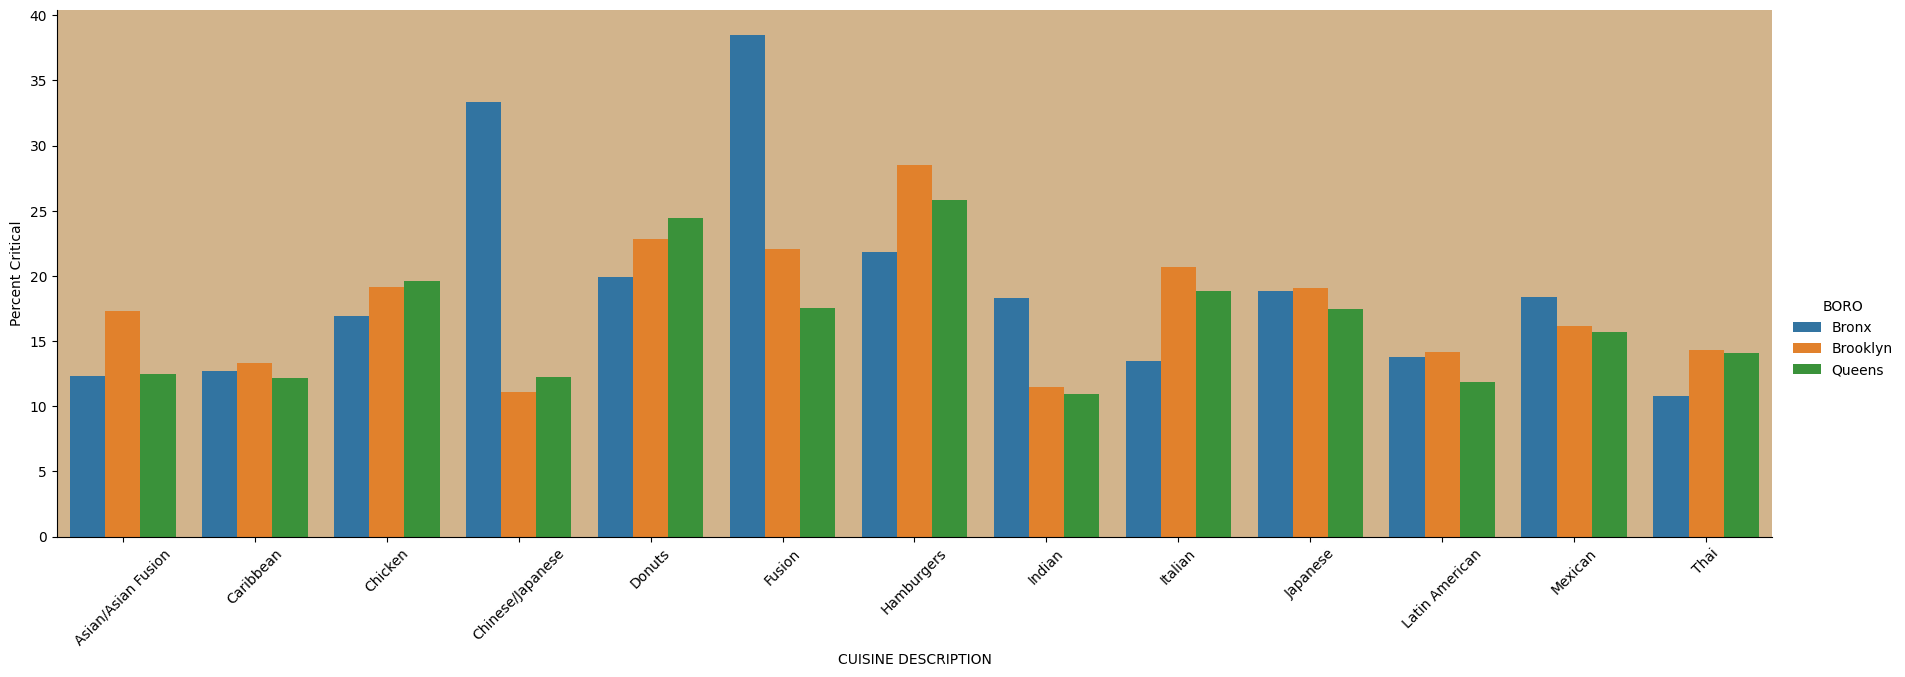

In [89]:
sns.set_style(rc={"axes.facecolor": "tan"})
sns.color_palette("mako", as_cmap=True)
sns.catplot(data=maxboro, y="Percent Critical", x="CUISINE DESCRIPTION", hue="BORO" ,kind="bar", height=6, aspect=3).set_xticklabels(rotation=45)

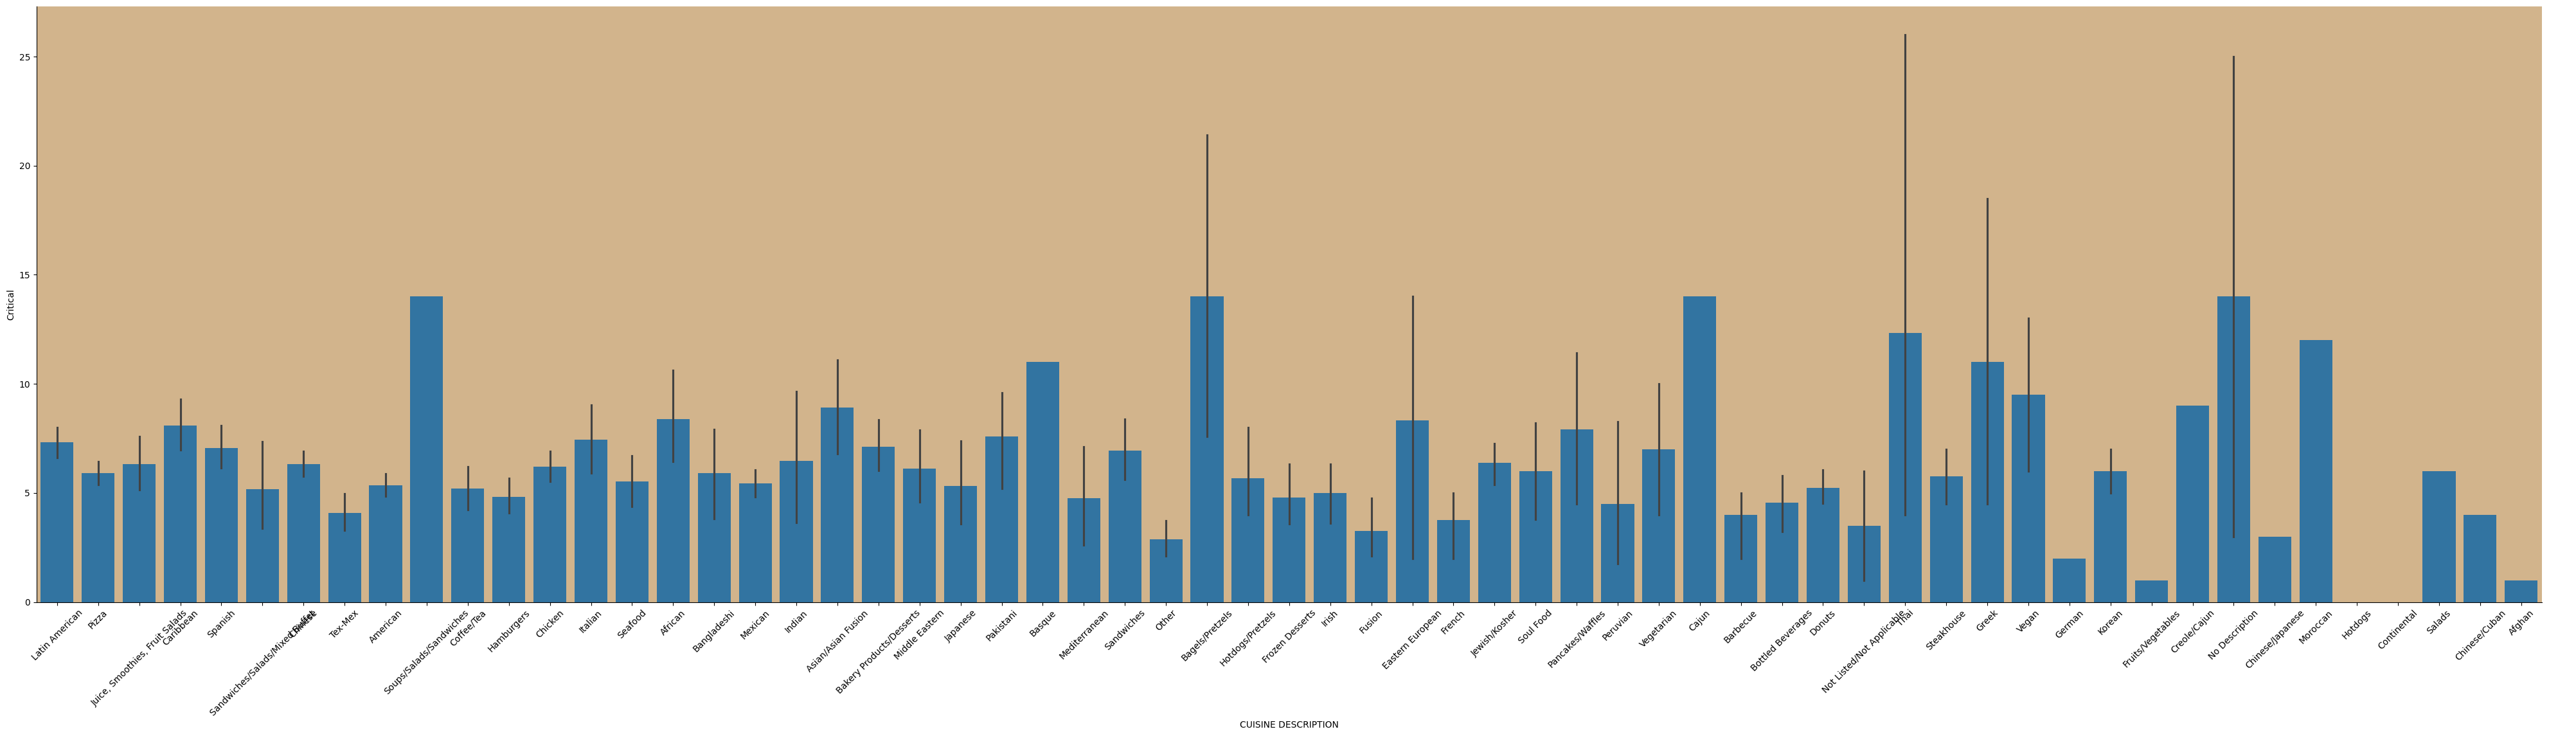

In [102]:
sns.catplot(data=BX, y="Critical", x="CUISINE DESCRIPTION",kind="bar", height=10, aspect=4).set_xticklabels(rotation=45)

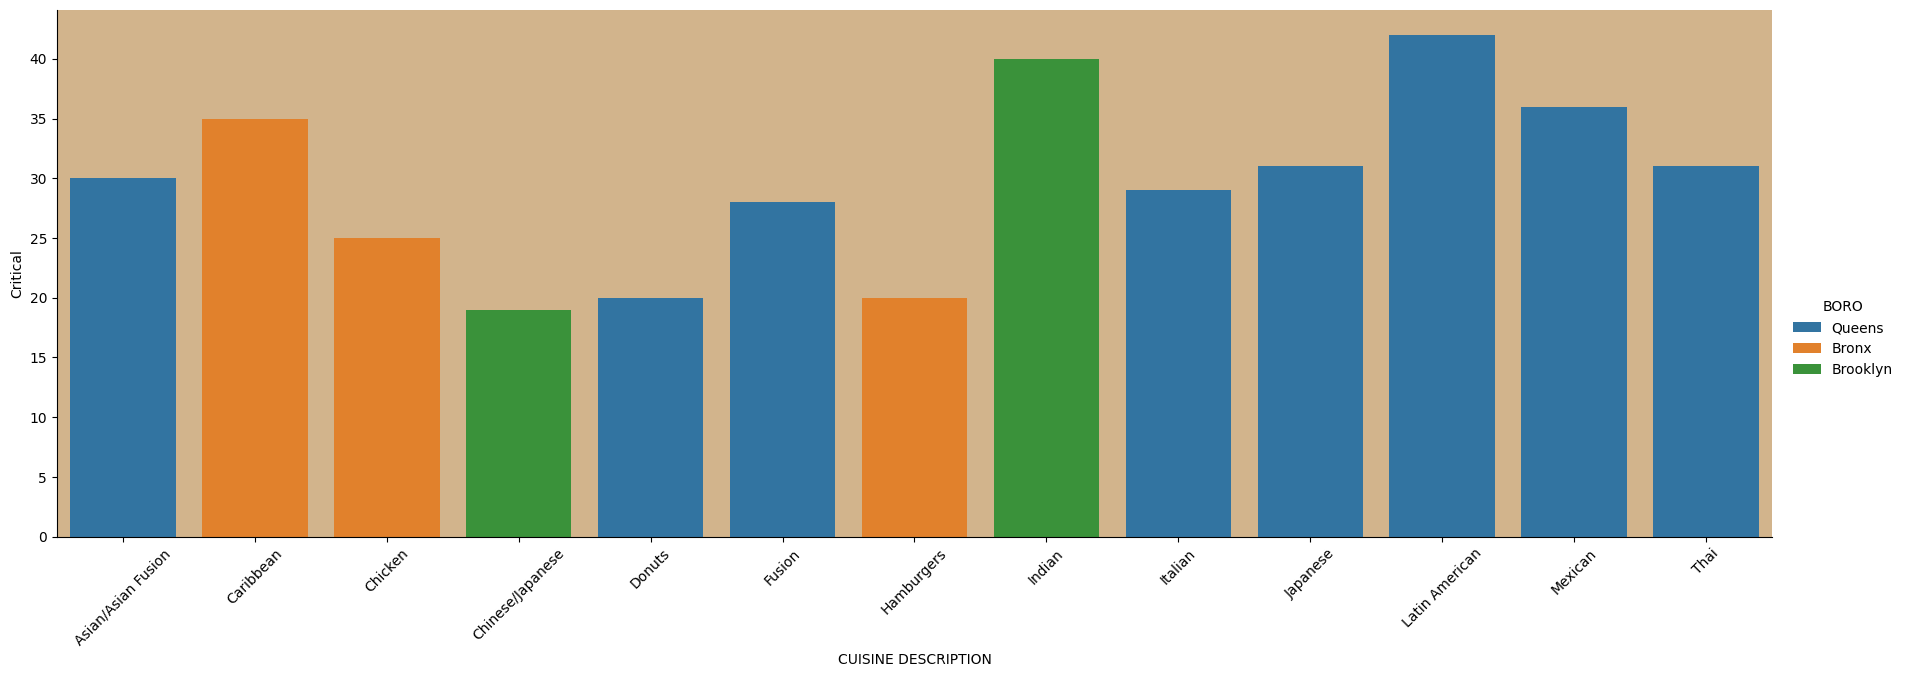

In [91]:
sns.color_palette("mako", as_cmap=True)
sns.catplot(data=maxBC, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="bar", height=6, aspect=3).set_xticklabels(rotation=45)

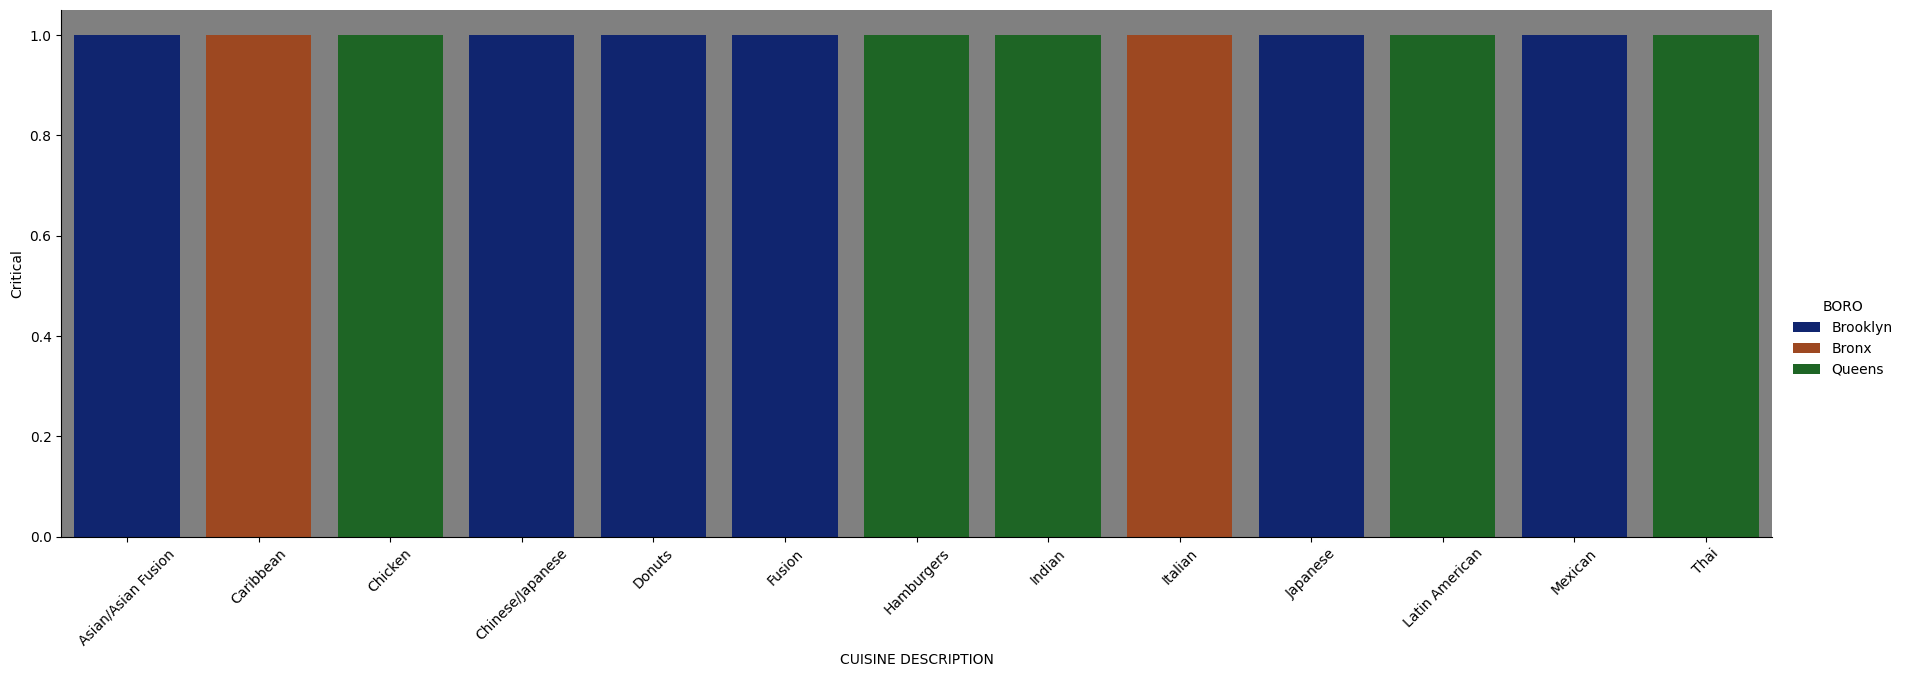

In [78]:
sns.catplot(data=MinBC, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="bar", height=6, aspect=3, palette='dark').set_xticklabels(rotation=45)

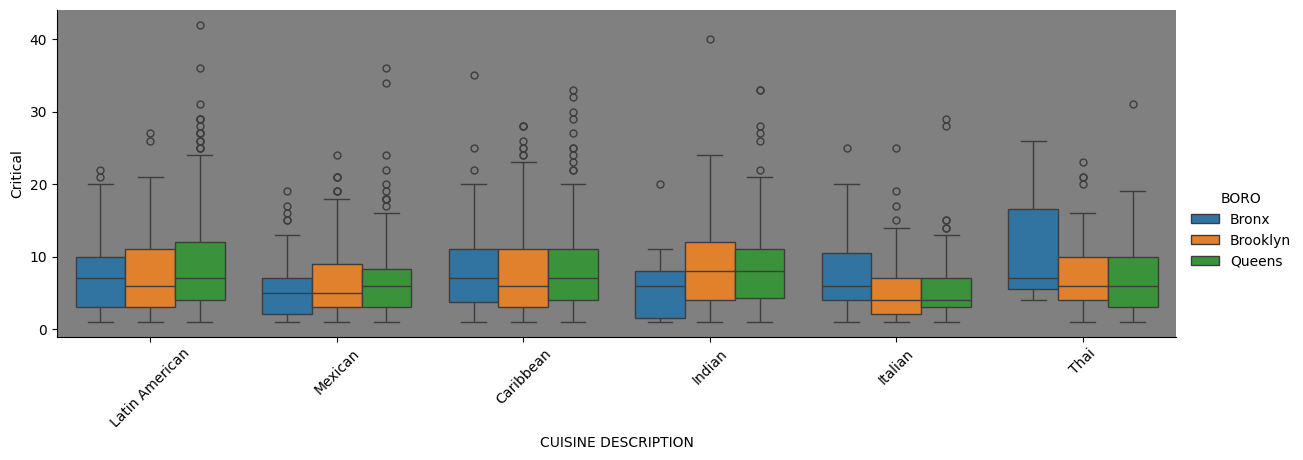

In [29]:
sns.catplot(data=flagfit, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="box", height=4, aspect=3).set_xticklabels(rotation=45)